In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans


In [2]:
# Step 1 - Load data
DATA_PATH = "/content/housing.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Loaded uploaded dataset:", DATA_PATH)
else:
    from sklearn.datasets import fetch_california_housing
    data = fetch_california_housing(as_frame=True)
    df = data.frame.copy()
    df.columns = [c.replace('-', '_') for c in df.columns]
    print("Loaded sklearn california housing dataset")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())


Loaded uploaded dataset: /content/housing.csv
Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Descriptive statistics (numeric):


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


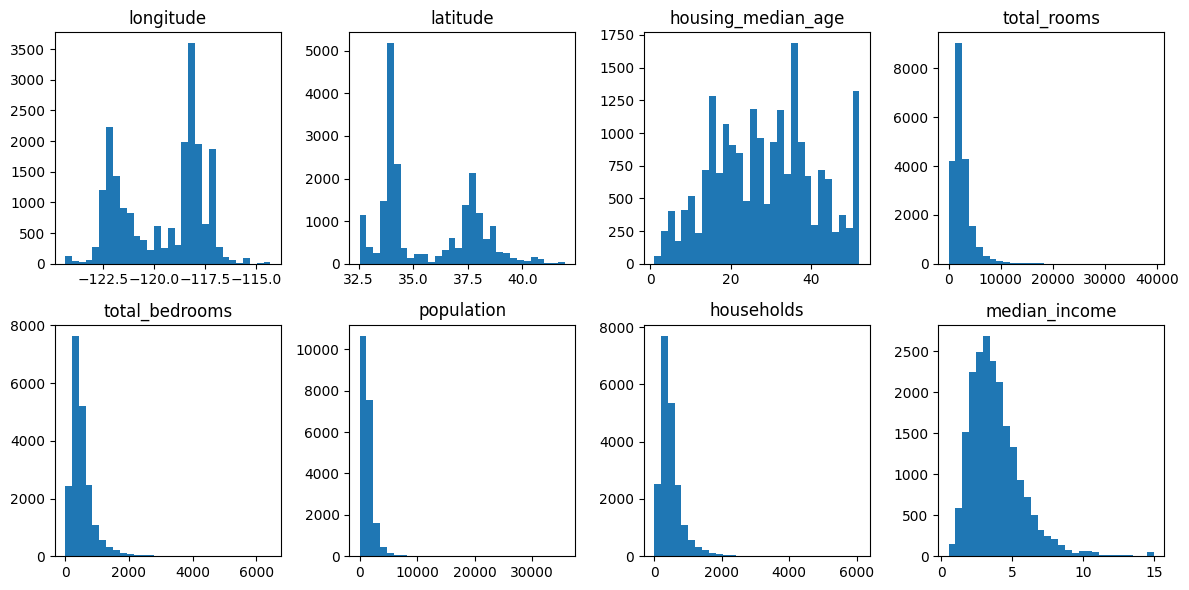

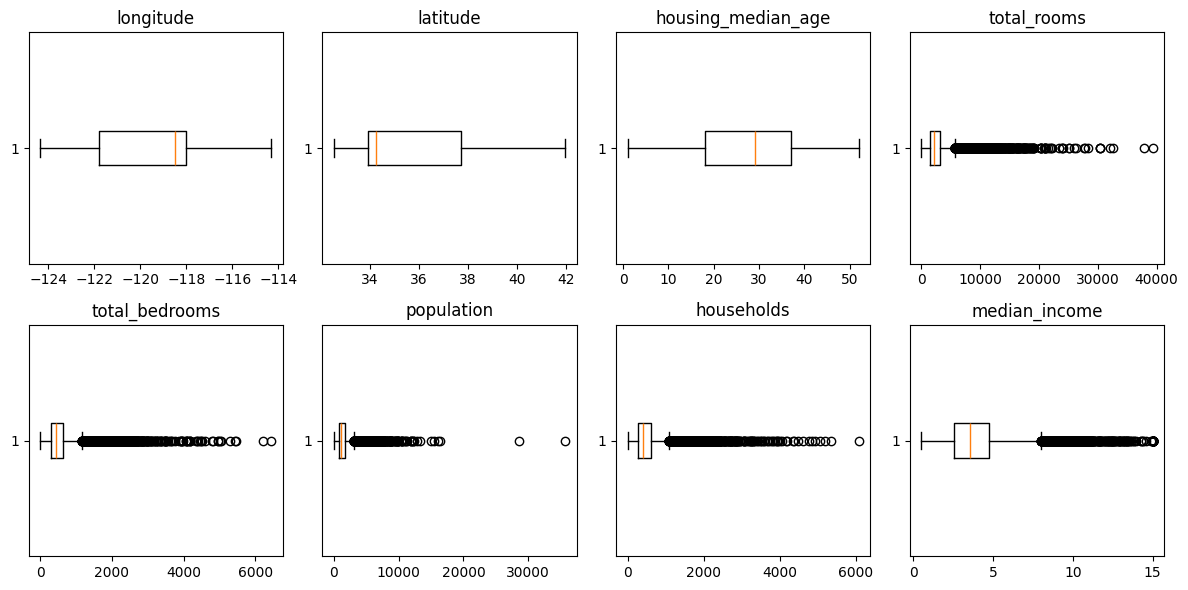

In [3]:
# Step 2 - EDA
print("Info:")
display(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDescriptive statistics (numeric):")
display(df.describe().T)

# Quick histograms for numeric columns (first up to 8)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols_to_plot = numeric_cols[:8]

plt.figure(figsize=(12,6))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2,4,i)
    plt.hist(df[col].dropna(), bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Boxplots to inspect outliers
plt.figure(figsize=(12,6))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2,4,i)
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
plt.tight_layout()
plt.show()


In [4]:
# Step 3 - choose target
possible_targets = [c for c in df.columns if c.lower() in (
    'medhouseval','median_house_value','saleprice','price','house_value','houseprice')]

if possible_targets:
    target = possible_targets[0]
    print("Auto-detected target:", target)
else:
    # fallback: use last numeric column; change if incorrect
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    target = numeric_cols[-1]
    print("No common target found. Using last numeric column as target:", target)

# Quick check
print("Target distribution summary:")
display(df[target].describe())


Auto-detected target: median_house_value
Target distribution summary:


,median_house_value
count,20640.000000
mean,206855.816909
std,115395.615874
min,14999.000000
25%,119600.000000
50%,179700.000000
75%,264725.000000
max,500001.000000


In [5]:
# Step 4 - create region if coordinates exist
if {'Latitude','Longitude'}.issubset(df.columns):
    coords = df[['Latitude','Longitude']].fillna(method='ffill').fillna(method='bfill')
    # choose clusters = 6 (tune if desired)
    kmeans = KMeans(n_clusters=6, random_state=42)
    df['region'] = kmeans.fit_predict(coords)
    print("Added 'region' column (kmeans clusters). Unique regions:", df['region'].nunique())
else:
    print("Latitude/Longitude not found — skipping 'region' creation.")


Latitude/Longitude not found — skipping 'region' creation.


In [13]:
# Step 5 - preprocessing pipelines
# Choose features
X = df.drop(columns=[target]).copy()
y = df[target].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
if 'region' in numeric_features:
    numeric_features.remove('region')
categorical_features = [c for c in X.columns if X[c].dtype == 'object' or c == 'region' or str(X[c].dtype).startswith('category')]

print("Numeric features:", numeric_features[:10])
print("Categorical features (detected):", categorical_features[:10])

# IQR capping function
def cap_outliers_iqr(X_array):
    X = X_array.copy() # X is now a NumPy array
    # Apply capping to each column of the NumPy array
    for i in range(X.shape[1]):
        col_data = X[:, i]
        q1 = np.percentile(col_data, 25)
        q3 = np.percentile(col_data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        X[:, i] = np.clip(col_data, lower, upper)
    return X

from sklearn.preprocessing import FunctionTransformer
cap_transformer = FunctionTransformer(cap_outliers_iqr)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('cap', cap_transformer), # Apply capping after imputation
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='drop')

print("Preprocessor ready.")

Numeric features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features (detected): ['ocean_proximity']
Preprocessor ready.


In [8]:
# Step 6 - train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (16512, 9) Test shape: (4128, 9)


In [14]:
# Step 7 - Linear models
from sklearn.linear_model import LinearRegression, Ridge

lr_pipeline = Pipeline([('preproc', preprocessor), ('lr', LinearRegression())])
ridge_pipeline = Pipeline([('preproc', preprocessor), ('ridge', Ridge(alpha=1.0))])

# use 3-fold CV for speed
kf = KFold(n_splits=3, shuffle=True, random_state=42)

for name, pipe in [('LinearRegression', lr_pipeline), ('Ridge', ridge_pipeline)]:
    cv_mse = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=1)
    cv_rmse = np.sqrt(-cv_mse).mean()
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, preds))
    test_r2 = r2_score(y_test, preds)
    print(f"{name} - CV RMSE: {cv_rmse:.4f} | Test RMSE: {test_rmse:.4f} | Test R²: {test_r2:.4f}")

# Show coefficients for linear model with feature names
lr_pipeline.fit(X_train, y_train)
ct = lr_pipeline.named_steps['preproc']
num_cols = numeric_features.copy()
try:
    ohe = ct.named_transformers_['cat'].named_steps['onehot']
    cat_names = list(ohe.get_feature_names_out(categorical_features))
except Exception:
    cat_names = []
feature_names = num_cols + cat_names
coefs = lr_pipeline.named_steps['lr'].coef_
coef_series = pd.Series(coefs, index=feature_names).sort_values(key=abs, ascending=False)
print("\nTop linear coefficients (abs sorted):")
display(coef_series.head(15))


LinearRegression - CV RMSE: 66484.7273 | Test RMSE: 70384.4061 | Test R²: 0.6220
Ridge - CV RMSE: 66477.1573 | Test RMSE: 70387.2146 | Test R²: 0.6219

Top linear coefficients (abs sorted):


,0
ocean_proximity_ISLAND,107667.039442
median_income,81433.708683
total_bedrooms,65829.355748
latitude,-52605.691346
longitude,-51669.780818
ocean_proximity_INLAND,-50991.434055
population,-50005.787083
total_rooms,-29127.134812
ocean_proximity_NEAR BAY,-25674.162067
households,17793.180724


RandomForest - CV RMSE: 50664.3501 | Test RMSE: 50047.8027 | Test R²: 0.8089

Top 15 feature importances (RandomForest):


,0
median_income,0.488945
ocean_proximity_INLAND,0.141256
longitude,0.107519
latitude,0.102250
housing_median_age,0.052285
population,0.032530
total_rooms,0.023428
total_bedrooms,0.023092
households,0.017705
ocean_proximity_NEAR OCEAN,0.006470


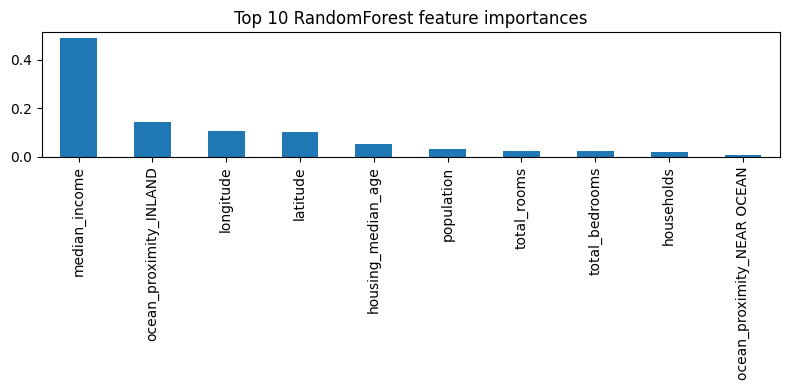

In [15]:
# Step 8 - Random Forest
rf_pipeline = Pipeline([('preproc', preprocessor),
                        ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1))])

cv_mse = cross_val_score(rf_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error', n_jobs=1)
cv_rmse = np.sqrt(-cv_mse).mean()
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_test_r2 = r2_score(y_test, rf_preds)
print(f"RandomForest - CV RMSE: {cv_rmse:.4f} | Test RMSE: {rf_test_rmse:.4f} | Test R²: {rf_test_r2:.4f}")

# Feature importances
ct = rf_pipeline.named_steps['preproc']
num_cols = numeric_features.copy()
try:
    ohe = ct.named_transformers_['cat'].named_steps['onehot']
    cat_names = list(ohe.get_feature_names_out(categorical_features))
except Exception:
    cat_names = []
feature_names = num_cols + cat_names
rf_model = rf_pipeline.named_steps['rf']
if hasattr(rf_model, 'feature_importances_'):
    fi = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("\nTop 15 feature importances (RandomForest):")
    display(fi.head(15))
    plt.figure(figsize=(8,4))
    fi.head(10).plot(kind='bar')
    plt.title("Top 10 RandomForest feature importances")
    plt.tight_layout()
    plt.show()


In [17]:
# Step 10 - results summary
results = []

def eval_pipeline(name, pipeline):
    preds = pipeline.predict(X_test)
    return {
        'model': name,
        'test_rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'test_r2': r2_score(y_test, preds)
    }

# ensure models are fitted
for name, pipe in [('LinearRegression', lr_pipeline),
                   ('Ridge', ridge_pipeline),
                   ('RandomForest', rf_pipeline)]:
    results.append(eval_pipeline(name, pipe))

results_df = pd.DataFrame(results).sort_values('test_rmse').reset_index(drop=True)
print("Model comparison (sorted by test RMSE):")
display(results_df)


Model comparison (sorted by test RMSE):


,model,test_rmse,test_r2
0,RandomForest,50047.802676,0.808855
1,LinearRegression,70384.406132,0.621953
2,Ridge,70387.214640,0.621923


In [19]:
# Step 11 - Save best model
import joblib
best_idx = results_df['test_rmse'].idxmin()
best_model_name = results_df.loc[best_idx, 'model']
print("Best model:", best_model_name)

# select the pipeline object
pipeline_map = {
    'LinearRegression': lr_pipeline,
    'Ridge': ridge_pipeline,
    'RandomForest': rf_pipeline
}
best_pipeline = pipeline_map.get(best_model_name, rf_pipeline)  # fallback
joblib.dump(best_pipeline, 'best_model_pipeline.joblib')
print("Saved pipeline to best_model_pipeline.joblib")

Best model: RandomForest
Saved pipeline to best_model_pipeline.joblib
